In [190]:
import os
from pathlib import Path
from collections import Counter
from PIL import Image
import random
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from collections import Counter
import random
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import hashlib
anime_data_path = Path("C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/")
print("Anime Dataset Exists:", anime_data_path.exists())
print("Contents (first 10):", list(anime_data_path.iterdir())[:10])
real_data_path = Path("C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/real/")
print("Real dataset Exists:", real_data_path.exists())
print("Contents (first 10):", list(real_data_path.iterdir())[:10])

Anime Dataset Exists: True
Contents (first 10): [WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00000.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00001.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00002.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00003.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00004.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00005.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00006.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00007.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00008.jpg'), WindowsPath('C:/Users/HP/Desktop/Face-Anime-AI/data/raw_data/anime/anime_00009.jpg')]
Real dataset Exists: True
Contents (first 10): [WindowsPath('C:/Users/HP/Desktop/Face-Anime

# Methods

In [191]:
def get_image_path(path):
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    images = [f for f in path.iterdir() if f.suffix.lower() in image_extensions]
    print(f"Found {len(images)} images")
    print(f"Total images: {len(images)}")
    return images

In [192]:
def get_corrupt_images(images):
    sizes = []              
    valid_images = []     
    corrupt_files = []

    for img_path in images:
        try:
            with Image.open(img_path) as img:
                img.verify()
            with Image.open(img_path) as img:
                sizes.append(img.size)   
            valid_images.append(img_path) 
        except (UnidentifiedImageError, OSError, Exception) as e:
            corrupt_files.append((img_path, str(e)))

    print(f"Valid images: {len(valid_images)}")
    print(f"Corrupt/unreadable images: {len(corrupt_files)}")

    if corrupt_files:
        print("\nCorrupt files found:")
        for path, err in corrupt_files[:20]:
            print(f"  {path.name} → {err}")

    size_counts = Counter(sizes)
    print("\nUnique sizes found:")
    for size, count in size_counts.most_common(10):
        print(f"{size}: {count} images")
    return valid_images,corrupt_files,size_counts

In [193]:
def show_random_images(valid_images):
    samples = random.sample(valid_images, min(5, len(valid_images)))

    fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [194]:
def channel_detection(valid_images):
    modes = []
    for img_path in valid_images:
        try:
            with Image.open(img_path) as img:
                modes.append(img.mode)
        except Exception:
            continue 

    mode_counts = Counter(modes)
    print("Color channel modes found:")
    for mode, count in mode_counts.most_common():
        print(f"{mode}: {count} images")
    return mode_counts

In [195]:
def compute_statistics(valid_images):
    sample_size = min(200, len(valid_images))
    sample_paths = random.sample(valid_images, sample_size)

    means, stds = [], []
    for img_path in sample_paths:
        try:
            with Image.open(img_path) as img:
                arr = np.array(img.convert("RGB")) / 255.0
                means.append(arr.mean(axis=(0, 1)))
                stds.append(arr.std(axis=(0, 1)))
        except Exception:
            continue

    means = np.array(means)
    stds = np.array(stds)

    print(f"Mean pixel value per channel (R,G,B): {means.mean(axis=0)}")
    print(f"Std pixel value per channel (R,G,B): {stds.mean(axis=0)}")
    return means,stds

In [196]:

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def duplicate_images(valid_images):
    hashes = {}
    duplicates = []

    for img_path in valid_images:
        h = file_hash(img_path)
        if h in hashes:
            duplicates.append((img_path, hashes[h]))
        else:
            hashes[h] = img_path

    print(f"Duplicate images found: {len(duplicates)}")
    for dup, original in duplicates[:20]:
        print(f"  {dup.name}  ==  {original.name}")
    return duplicates

In [197]:
def summary(images,valid_images,corrupt_files,duplicates,means,mode_counts,size_counts):
    print("=" * 50)
    print("DATASET SUMMARY")
    print("=" * 50)
    print(f"Total images found:      {len(images)}")
    print(f"Valid images:            {len(valid_images)}")
    print(f"Corrupt images:          {len(corrupt_files)}")
    print(f"Duplicate images:        {len(duplicates)}")
    print(f"Unique image sizes:      {len(size_counts)}")
    print(f"Most common size:        {size_counts.most_common(1)[0] if size_counts else 'N/A'}")
    print(f"Color modes present:     {dict(mode_counts)}")
    print(f"Mean pixel (R,G,B):      {means.mean(axis=0).round(3) if len(means) else 'N/A'}")
    print("=" * 50)

    print("\nRecommended next steps:")
    if corrupt_files:
        print(f"- Remove or fix {len(corrupt_files)} corrupt images before training")
    if duplicates:
        print(f"- Remove {len(duplicates)} duplicate images to avoid data leakage")
    if len(size_counts) > 1:
        print(f"- Images have {len(size_counts)} different sizes — add a resize step in your data pipeline")
    if len(mode_counts) > 1:
        print(f"- Mixed color modes detected — convert all to RGB with img.convert('RGB') during loading")

# Exploratory Data Analysis for Anime Data

Found 63565 images
Total images: 63565
Valid images: 59667
Corrupt/unreadable images: 3898

Corrupt files found:
  anime_31792.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31792.jpg'
  anime_31861.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31861.jpg'
  anime_31869.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31869.jpg'
  anime_31917.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31917.jpg'
  anime_31931.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31931.jpg'
  anime_31952.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31952.jpg'
  anime_31987.jpg → cannot identify image file 'C:\\Users\\HP\\Desktop\\Face-Anime-AI\\data\\raw_data\\anime\\anime_31987.jpg

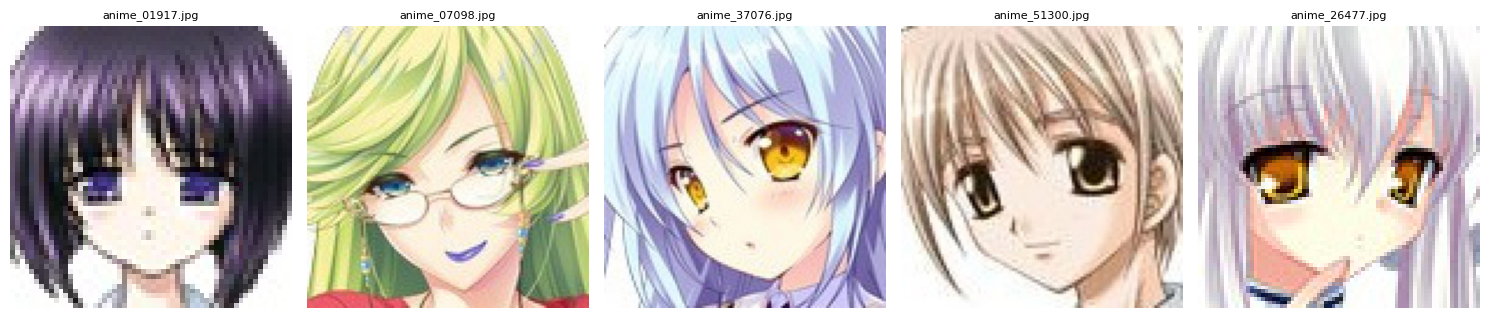

Color channel modes found:
RGB: 59667 images
Mean pixel value per channel (R,G,B): [0.68142167 0.58496072 0.5688013 ]
Std pixel value per channel (R,G,B): [0.25796626 0.26692334 0.2442455 ]
Duplicate images found: 19788
  anime_00216.jpg  ==  anime_00056.jpg
  anime_00448.jpg  ==  anime_00102.jpg
  anime_00785.jpg  ==  anime_00454.jpg
  anime_00799.jpg  ==  anime_00705.jpg
  anime_00833.jpg  ==  anime_00285.jpg
  anime_00909.jpg  ==  anime_00285.jpg
  anime_00983.jpg  ==  anime_00254.jpg
  anime_01049.jpg  ==  anime_00434.jpg
  anime_01069.jpg  ==  anime_00202.jpg
  anime_01142.jpg  ==  anime_00596.jpg
  anime_01199.jpg  ==  anime_01101.jpg
  anime_01223.jpg  ==  anime_01161.jpg
  anime_01271.jpg  ==  anime_01091.jpg
  anime_01290.jpg  ==  anime_00230.jpg
  anime_01309.jpg  ==  anime_00411.jpg
  anime_01310.jpg  ==  anime_00928.jpg
  anime_01378.jpg  ==  anime_00744.jpg
  anime_01382.jpg  ==  anime_00976.jpg
  anime_01391.jpg  ==  anime_01029.jpg
  anime_01484.jpg  ==  anime_00529.jpg


In [198]:
anime_images=get_image_path(anime_data_path)
valid_anime_images,corrupt_anime_files,anime_size_count=get_corrupt_images(anime_images)
show_random_images(valid_anime_images)
anime_mode_count=channel_detection(valid_anime_images)
anime_means,anime_stds=compute_statistics(valid_anime_images)
duplicate_anime_images=duplicate_images(valid_anime_images)
summary(anime_images,valid_anime_images,corrupt_anime_files,duplicate_anime_images,anime_means,anime_mode_count,anime_size_count)


# Exploratory Data Analysis For Real_Data

Found 202599 images
Total images: 202599
Valid images: 202599
Corrupt/unreadable images: 0

Unique sizes found:
(178, 218): 202599 images


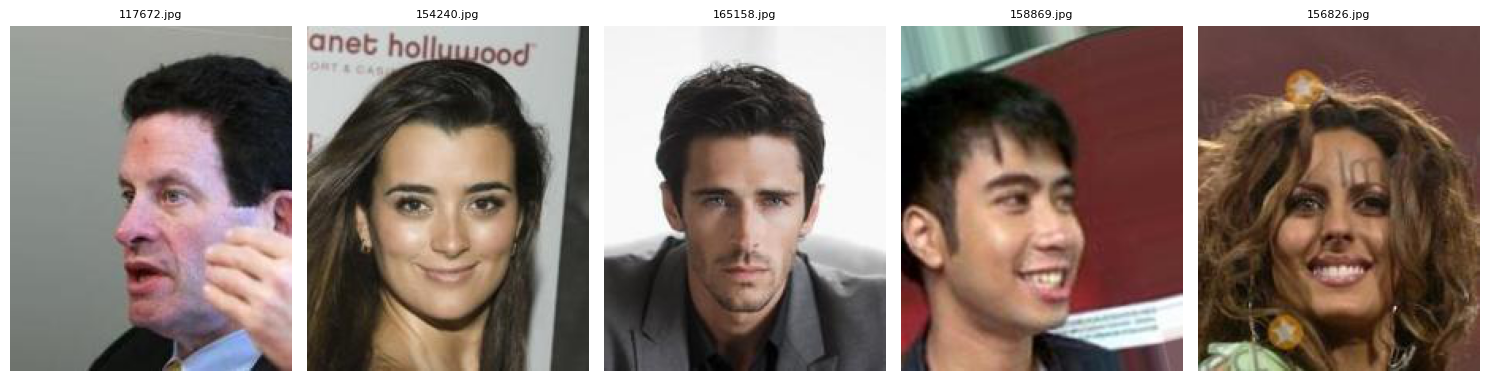

Color channel modes found:
RGB: 202599 images
Mean pixel value per channel (R,G,B): [0.49881394 0.41900022 0.37636776]
Std pixel value per channel (R,G,B): [0.26601037 0.24637852 0.24168536]
Duplicate images found: 131
  014364.jpg  ==  012589.jpg
  019471.jpg  ==  007227.jpg
  021423.jpg  ==  019673.jpg
  049003.jpg  ==  011318.jpg
  055807.jpg  ==  030146.jpg
  056985.jpg  ==  015484.jpg
  057990.jpg  ==  043513.jpg
  058721.jpg  ==  020782.jpg
  065708.jpg  ==  047447.jpg
  066034.jpg  ==  002538.jpg
  069351.jpg  ==  029535.jpg
  069531.jpg  ==  030206.jpg
  070147.jpg  ==  057127.jpg
  072850.jpg  ==  012069.jpg
  073219.jpg  ==  072611.jpg
  074402.jpg  ==  051286.jpg
  074740.jpg  ==  069407.jpg
  078159.jpg  ==  001853.jpg
  079927.jpg  ==  033991.jpg
  081870.jpg  ==  052475.jpg
DATASET SUMMARY
Total images found:      202599
Valid images:            202599
Corrupt images:          0
Duplicate images:        131
Unique image sizes:      1
Most common size:        ((178, 218), 

In [199]:
real_images=get_image_path(real_data_path)
valid_real_images,corrupt_real_files,real_size_count=get_corrupt_images(real_images)
show_random_images(valid_real_images)
real_mode_count=channel_detection(valid_real_images)
real_means,real_stds=compute_statistics(valid_real_images)
duplicate_real_images=duplicate_images(valid_real_images)
summary(real_images,valid_real_images,corrupt_real_files,duplicate_real_images,real_means,real_mode_count,real_size_count)
